# 🏥 Hospital Pipeline — Simple Version

**Flow (easy to follow):**
`Load CSV → Check data → Risk score → Booked schedule → Emergency handling → Confirmation messages → Charts → Save files`

Rules we follow:
- Emergency patient is seen **immediately**.
- Patients booked with that doctor are moved to **another doctor at the same time** (no late).
- Every moved patient gets a **confirmation message**.

Keep `hospital_patients_100.csv` in the same folder as this notebook.

## Step 1 — Load the CSV
Read the file and look at the first rows.

In [1]:
import pandas as pd

df = pd.read_csv("hospital_patients_100.csv", keep_default_na=False, na_values=[""])
print("Rows, columns:", df.shape)
df[["patient_id", "patient_name", "department", "appointment_type", "appointment_date", "appointment_time", "doctor_name"]].head()

Rows, columns: (100, 36)


,patient_id,patient_name,department,appointment_type,appointment_date,appointment_time,doctor_name
0,PAT-1001,Rohan Iyer,Neurology,Advance,2026-09-22,14:15,Dr. Vikram Rao
1,PAT-1002,Chaitanya Menon,Neurology,Advance,2026-09-21,12:45,Dr. Vikram Rao
2,PAT-1003,Neha Iyer,Cardiology,Advance,2026-09-21,10:45,Dr. Ramesh Naidu
3,PAT-1004,Pooja Yadav,Cardiology,Advance,2026-09-21,10:30,Dr. Sneha Reddy
4,PAT-1005,Sandeep Menon,Orthopedics,Advance,2026-09-24,15:30,Dr. Kavitha Menon


## Step 2 — Quick data check
Find duplicates, missing values and double bookings.
(Emergency patients have no doctor yet, so blank doctor for them is normal.)

In [2]:
print("Duplicate patients :", df.patient_id.duplicated().sum())
print("Missing values     :")
print(df.isna().sum()[df.isna().sum() > 0].to_string())
print()
print(df.appointment_type.value_counts().to_string())

booked = df[df.appointment_type == "Advance"]
print("\nDouble bookings    :", booked.duplicated(["doctor_id", "appointment_date", "appointment_time"]).sum())

Duplicate patients : 0
Missing values     :
appointment_id    12
doctor_id         12
doctor_name       12

appointment_type
Advance      88
Emergency    12

Double bookings    : 0


## Step 3 — Doctors list
3 doctors in every department. The first doctor in each list is the senior (emergency lead).

In [3]:
doctors = {
    "Cardiology": {'DOC-CAR-01': 'Dr. Ramesh Naidu', 'DOC-CAR-02': 'Dr. Sneha Reddy', 'DOC-CAR-03': 'Dr. Arun Kumar'},
    "Neurology": {'DOC-NEU-01': 'Dr. Lakshmi Prasad', 'DOC-NEU-02': 'Dr. Vikram Rao', 'DOC-NEU-03': 'Dr. Meena Iyer'},
    "Orthopedics": {'DOC-ORT-01': 'Dr. Suresh Babu', 'DOC-ORT-02': 'Dr. Kavitha Menon', 'DOC-ORT-03': 'Dr. Imran Shaikh'},
    "General Medicine": {'DOC-GEN-01': 'Dr. Anil Sharma', 'DOC-GEN-02': 'Dr. Padma Latha', 'DOC-GEN-03': 'Dr. Rohit Verma'},
    "Pediatrics": {'DOC-PED-01': 'Dr. Swathi Chowdary', 'DOC-PED-02': 'Dr. Karthik Reddy', 'DOC-PED-03': 'Dr. Fatima Begum'},
    "Pulmonology": {'DOC-PUL-01': 'Dr. Venkat Rao', 'DOC-PUL-02': 'Dr. Anjali Singh', 'DOC-PUL-03': 'Dr. Prakash Nair'},
}

doctor_name = {doc_id: name for dept in doctors.values() for doc_id, name in dept.items()}
print("Departments:", list(doctors))
print("Total doctors:", len(doctor_name))

Departments: ['Cardiology', 'Neurology', 'Orthopedics', 'General Medicine', 'Pediatrics', 'Pulmonology']
Total doctors: 18


## Step 4 — Risk score (simple)
Give **1 point** for each danger sign in the vitals:
high/low heart rate, low SpO₂, abnormal BP, fever, abnormal breathing rate, not fully alert.

- 3 or more points → **High** risk
- 1–2 points → **Medium**
- 0 points → **Low**

In [4]:
def risk_points(r):
    p = 0
    p += int(r.heart_rate > 100 or r.heart_rate < 50)
    p += int(r.spo2 < 95)
    p += int(r.systolic_bp < 105 or r.systolic_bp > 180)
    p += int(r.temperature_c >= 38)
    p += int(r.resp_rate > 20 or r.resp_rate < 10)
    p += int(r.consciousness != "Alert")
    return p

df["risk_points"] = df.apply(risk_points, axis=1)
df["risk_level"] = pd.cut(df.risk_points, [-1, 0, 2, 10], labels=["Low", "Medium", "High"])
df["minute"] = df.appointment_time.str[:2].astype(int) * 60 + df.appointment_time.str[3:].astype(int)

print(df.groupby("appointment_type").risk_level.value_counts().unstack().to_string())
print("\nHigh-risk booked patients (nurse should call before visit):")
df[(df.appointment_type == "Advance") & (df.risk_level == "High")][["patient_id", "department", "appointment_date", "appointment_time", "risk_points"]]

risk_level        Low  Medium  High
appointment_type                   
Advance            72      10     6
Emergency           0       2    10

High-risk booked patients (nurse should call before visit):


,patient_id,department,appointment_date,appointment_time,risk_points
0,PAT-1001,Neurology,2026-09-22,14:15,3
38,PAT-1039,Pediatrics,2026-09-21,09:15,4
45,PAT-1046,General Medicine,2026-09-25,12:30,3
46,PAT-1047,Cardiology,2026-09-21,09:30,3
56,PAT-1057,Pediatrics,2026-09-22,15:15,3
80,PAT-1081,General Medicine,2026-09-25,12:30,3


## Step 5 — Booked schedule (advance appointments)
Copy the 88 advance appointments into a `schedule` table. We will change this table when emergencies come.

In [5]:
schedule = df[df.appointment_type == "Advance"][["appointment_id", "patient_id", "patient_name", "phone", "department",
                                                  "appointment_date", "appointment_time", "minute", "doctor_id"]].copy()
schedule["original_doctor"] = schedule.doctor_id
schedule["original_minute"] = schedule.minute
schedule["status"] = "Confirmed"

print("Booked appointments:", len(schedule))
schedule.head()

Booked appointments: 88


,appointment_id,patient_id,patient_name,phone,department,appointment_date,appointment_time,minute,doctor_id,original_doctor,original_minute,status
0,APT-0061,PAT-1001,Rohan Iyer,+91 56669 06861,Neurology,2026-09-22,14:15,855,DOC-NEU-02,DOC-NEU-02,855,Confirmed
1,APT-0002,PAT-1002,Chaitanya Menon,+91 55523 05807,Neurology,2026-09-21,12:45,765,DOC-NEU-02,DOC-NEU-02,765,Confirmed
2,APT-0008,PAT-1003,Neha Iyer,+91 54155 74915,Cardiology,2026-09-21,10:45,645,DOC-CAR-01,DOC-CAR-01,645,Confirmed
3,APT-0003,PAT-1004,Pooja Yadav,+91 54776 84036,Cardiology,2026-09-21,10:30,630,DOC-CAR-02,DOC-CAR-02,630,Confirmed
4,APT-0039,PAT-1005,Sandeep Menon,+91 56535 58605,Orthopedics,2026-09-24,15:30,930,DOC-ORT-02,DOC-ORT-02,930,Confirmed


## Step 6 — Emergency queue
Emergency patients in order of arrival.
The more danger points, the longer the doctor is busy with the patient:
- 5+ points → 60 min  ·  3–4 points → 45 min  ·  less → 30 min

In [6]:
def block_minutes(points):
    return 60 if points >= 5 else 45 if points >= 3 else 30

emergencies = df[df.appointment_type == "Emergency"].sort_values(["appointment_date", "minute"]).copy()
emergencies["busy_minutes"] = emergencies.risk_points.map(block_minutes)
emergencies[["patient_id", "department", "appointment_date", "appointment_time", "primary_complaint", "risk_points", "busy_minutes"]]

,patient_id,department,appointment_date,appointment_time,primary_complaint,risk_points,busy_minutes
88,PAT-1089,Cardiology,2026-09-21,10:15,Severe chest pain radiating to left arm (suspe...,5,60
90,PAT-1091,Cardiology,2026-09-21,10:30,Severe chest pain radiating to left arm (suspe...,4,45
89,PAT-1090,Neurology,2026-09-21,11:00,Sudden facial droop and slurred speech (suspec...,2,30
91,PAT-1092,Pulmonology,2026-09-21,14:30,Acute severe breathlessness (suspected respira...,6,60
93,PAT-1094,Orthopedics,2026-09-22,09:45,Road traffic accident with suspected femur fra...,1,30
94,PAT-1095,General Medicine,2026-09-22,11:15,High fever with confusion (suspected sepsis),4,45
92,PAT-1093,Pediatrics,2026-09-22,15:00,Febrile seizure in a child,4,45
95,PAT-1096,Cardiology,2026-09-23,12:00,Severe chest pain radiating to left arm (suspe...,5,60
96,PAT-1097,Neurology,2026-09-23,15:15,Sudden facial droop and slurred speech (suspec...,3,45
98,PAT-1099,Orthopedics,2026-09-24,10:00,Road traffic accident with suspected femur fra...,4,45


## Step 7 — Handle emergencies (main logic)
For every emergency, in order:
1. **Choose doctor** — most senior doctor of that department who is free.
2. **Find booked patients** of that doctor during the emergency time.
3. **Move each patient** to another doctor at the **same time** — same department first, then General Medicine.
4. **Write a confirmation message** for each moved patient.
5. If nobody is free, mark the patient as `Call patient` (manual call).

In [7]:
er_blocks = []    # (doctor, date, start_minute, end_minute)
messages  = []    # confirmation messages
er_events = []    # one line per emergency

def is_free(doc, date, minute):
    """Doctor has no booking at that time and is not busy with an emergency."""
    has_booking = ((schedule.doctor_id == doc) & (schedule.appointment_date == date) & (schedule.minute == minute)).any()
    in_emergency = any(b[0] == doc and b[1] == date and b[2] <= minute < b[3] for b in er_blocks)
    return not has_booking and not in_emergency

for e in emergencies.itertuples():
    start, end = e.minute, e.minute + e.busy_minutes
    dept_docs = list(doctors[e.department])

    # 1) choose the emergency doctor
    er_doc = dept_docs[0]
    for doc in dept_docs:
        busy = any(b[0] == doc and b[1] == e.appointment_date and b[2] < end and start < b[3] for b in er_blocks)
        if not busy:
            er_doc = doc
            break
    er_blocks.append((er_doc, e.appointment_date, start, end))

    # 2) booked patients of this doctor during the emergency
    affected = schedule[(schedule.doctor_id == er_doc) & (schedule.appointment_date == e.appointment_date) &
                        (schedule.minute >= start) & (schedule.minute < end)]

    # 3) move each patient to another doctor at the same time
    backup_docs = [] if e.department == "Pediatrics" else list(doctors["General Medicine"])
    for i, row in affected.iterrows():
        new_doc = None
        for doc in [d for d in dept_docs if d != er_doc] + backup_docs:
            if is_free(doc, row.appointment_date, row.minute):
                new_doc = doc
                break

        if new_doc:
            schedule.loc[i, "doctor_id"] = new_doc
            schedule.loc[i, "status"] = "Re-confirmed"
            messages.append({
                "patient_id": row.patient_id, "patient_name": row.patient_name,
                "phone": "XXXXXXX" + row.phone[-3:], "appointment_id": row.appointment_id,
                "message": (f"Dear {row.patient_name}, due to an emergency your appointment on {row.appointment_date} "
                            f"is moved to {doctor_name[new_doc]}. Time is SAME: {row.appointment_time}. Confirmed.")})
        else:
            schedule.loc[i, "status"] = "Call patient"

    er_events.append({"patient_id": e.patient_id, "department": e.department, "date": e.appointment_date,
                      "arrival": e.appointment_time, "risk_points": e.risk_points,
                      "emergency_doctor": doctor_name[er_doc], "doctor_busy_until": f"{end // 60:02d}:{end % 60:02d}",
                      "patients_moved": len(affected)})

er_events = pd.DataFrame(er_events)
er_events

,patient_id,department,date,arrival,risk_points,emergency_doctor,doctor_busy_until,patients_moved
0,PAT-1089,Cardiology,2026-09-21,10:15,5,Dr. Ramesh Naidu,11:15,2
1,PAT-1091,Cardiology,2026-09-21,10:30,4,Dr. Sneha Reddy,11:15,3
2,PAT-1090,Neurology,2026-09-21,11:00,2,Dr. Lakshmi Prasad,11:30,2
3,PAT-1092,Pulmonology,2026-09-21,14:30,6,Dr. Venkat Rao,15:30,2
4,PAT-1094,Orthopedics,2026-09-22,09:45,1,Dr. Suresh Babu,10:15,2
5,PAT-1095,General Medicine,2026-09-22,11:15,4,Dr. Anil Sharma,12:00,2
6,PAT-1093,Pediatrics,2026-09-22,15:00,4,Dr. Swathi Chowdary,15:45,3
7,PAT-1096,Cardiology,2026-09-23,12:00,5,Dr. Ramesh Naidu,13:00,3
8,PAT-1097,Neurology,2026-09-23,15:15,3,Dr. Lakshmi Prasad,16:00,2
9,PAT-1099,Orthopedics,2026-09-24,10:00,4,Dr. Suresh Babu,10:45,3


## Step 8 — Check the result
Did anyone get late? Any clash? Was everybody confirmed?

In [8]:
schedule["delay_min"] = schedule.minute - schedule.original_minute

clashes = 0
for doc, date, start, end in er_blocks:
    clashes += len(schedule[(schedule.doctor_id == doc) & (schedule.appointment_date == date) &
                            (schedule.minute >= start) & (schedule.minute < end)])

print("Emergencies handled       :", len(er_events))
print("Booked patients moved     :", (schedule.status == "Re-confirmed").sum())
print("Patients needing a call   :", (schedule.status == "Call patient").sum())
print("Maximum delay (minutes)   :", schedule.delay_min.max())
print("Double bookings           :", schedule.duplicated(["doctor_id", "appointment_date", "minute"]).sum())
print("Bookings inside ER time   :", clashes)
print("Confirmation messages     :", len(messages), "(1 per move; a patient moved twice gets 2 messages)")

Emergencies handled       : 12
Booked patients moved     : 23
Patients needing a call   : 0
Maximum delay (minutes)   : 0
Double bookings           : 0
Bookings inside ER time   : 0
Confirmation messages     : 24 (1 per move; a patient moved twice gets 2 messages)


## Step 9 — Before vs after (moved patients)
Same time, different doctor.

In [9]:
moved = schedule[schedule.status == "Re-confirmed"].copy()
moved["old_doctor"] = moved.original_doctor.map(doctor_name)
moved["new_doctor"] = moved.doctor_id.map(doctor_name)
moved[["appointment_id", "patient_name", "appointment_date", "appointment_time", "old_doctor", "new_doctor", "delay_min"]].head(10)

,appointment_id,patient_name,appointment_date,appointment_time,old_doctor,new_doctor,delay_min
2,APT-0008,Neha Iyer,2026-09-21,10:45,Dr. Ramesh Naidu,Dr. Arun Kumar,0
3,APT-0003,Pooja Yadav,2026-09-21,10:30,Dr. Sneha Reddy,Dr. Arun Kumar,0
8,APT-0077,Divya Iyer,2026-09-23,12:15,Dr. Ramesh Naidu,Dr. Sneha Reddy,0
9,APT-0067,Suresh Sharma,2026-09-22,09:45,Dr. Suresh Babu,Dr. Kavitha Menon,0
17,APT-0016,Bhaskar Chowdary,2026-09-24,10:15,Dr. Suresh Babu,Dr. Kavitha Menon,0
21,APT-0052,Ayesha Goud,2026-09-23,12:00,Dr. Ramesh Naidu,Dr. Sneha Reddy,0
25,APT-0047,Anusha Menon,2026-09-21,10:45,Dr. Sneha Reddy,Dr. Anil Sharma,0
29,APT-0013,Neha Singh,2026-09-21,15:15,Dr. Venkat Rao,Dr. Anjali Singh,0
37,APT-0036,Lokesh Nair,2026-09-21,11:00,Dr. Ramesh Naidu,Dr. Arun Kumar,0
42,APT-0046,Anitha Chowdary,2026-09-24,10:00,Dr. Suresh Babu,Dr. Kavitha Menon,0


## Step 10 — Confirmation messages
This is what the patients receive (SMS / WhatsApp in real life).

In [10]:
messages = pd.DataFrame(messages)
for m in messages.head(3).itertuples():
    print(f"To {m.phone}:\n  {m.message}\n")
print("Total messages:", len(messages))

To XXXXXXX915:
  Dear Neha Iyer, due to an emergency your appointment on 2026-09-21 is moved to Dr. Arun Kumar. Time is SAME: 10:45. Confirmed.

To XXXXXXX483:
  Dear Lokesh Nair, due to an emergency your appointment on 2026-09-21 is moved to Dr. Sneha Reddy. Time is SAME: 11:00. Confirmed.

To XXXXXXX036:
  Dear Pooja Yadav, due to an emergency your appointment on 2026-09-21 is moved to Dr. Arun Kumar. Time is SAME: 10:30. Confirmed.

Total messages: 24


## Step 11 — Pie charts
Four pie charts show the big picture: who came, how risky they are, which departments are busy, and how many bookings had to change.

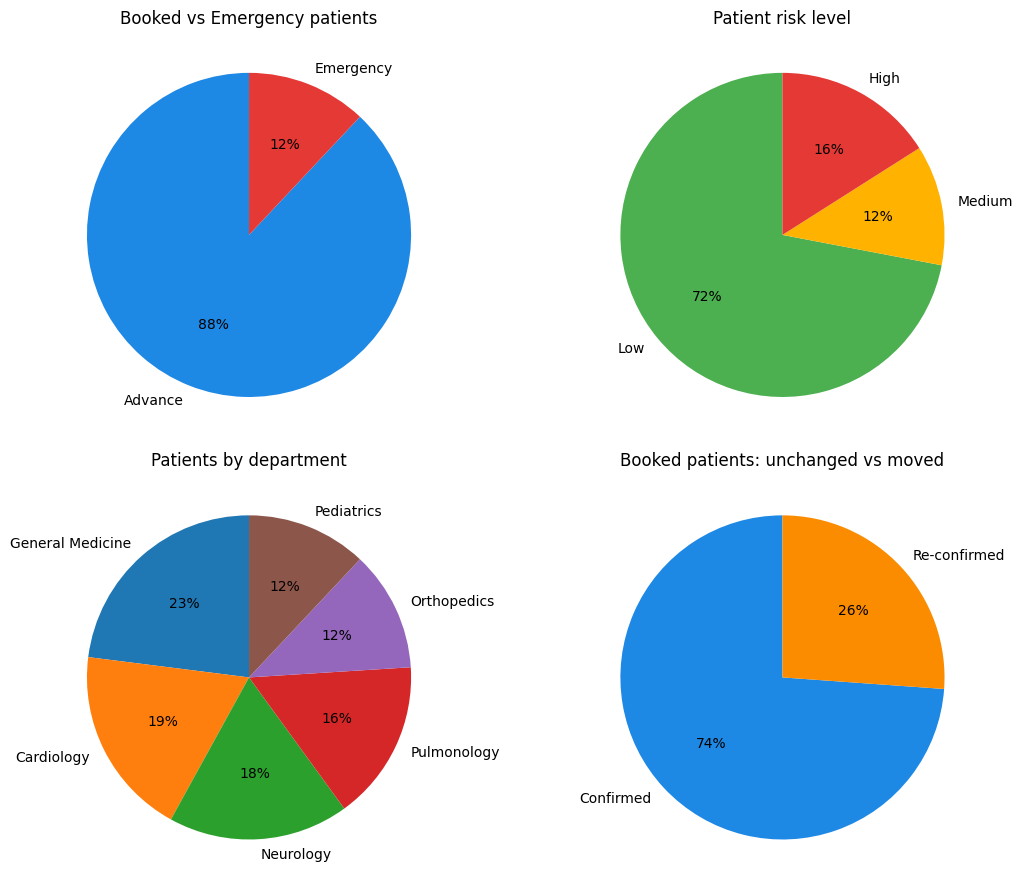

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(11, 9))

df.appointment_type.value_counts().plot.pie(ax=ax[0, 0], autopct="%1.0f%%", startangle=90, colors=["#1e88e5", "#e53935"])
ax[0, 0].set_title("Booked vs Emergency patients")

df.risk_level.value_counts().reindex(["Low", "Medium", "High"]).plot.pie(
    ax=ax[0, 1], autopct="%1.0f%%", startangle=90, colors=["#4caf50", "#ffb300", "#e53935"])
ax[0, 1].set_title("Patient risk level")

df.department.value_counts().plot.pie(ax=ax[1, 0], autopct="%1.0f%%", startangle=90)
ax[1, 0].set_title("Patients by department")

schedule.status.value_counts().plot.pie(ax=ax[1, 1], autopct="%1.0f%%", startangle=90, colors=["#1e88e5", "#fb8c00", "#e53935"])
ax[1, 1].set_title("Booked patients: unchanged vs moved")

for a in ax.flat:
    a.set_ylabel("")
plt.tight_layout()
plt.show()

## Step 12 — Bar and line graphs
1. **Bar:** booked appointments per day
2. **Line:** how busy each hour of the day is
3. **Bar:** how many booked patients each emergency displaced (all were moved with 0 delay)
4. **Bar:** patients per doctor, before vs after emergencies

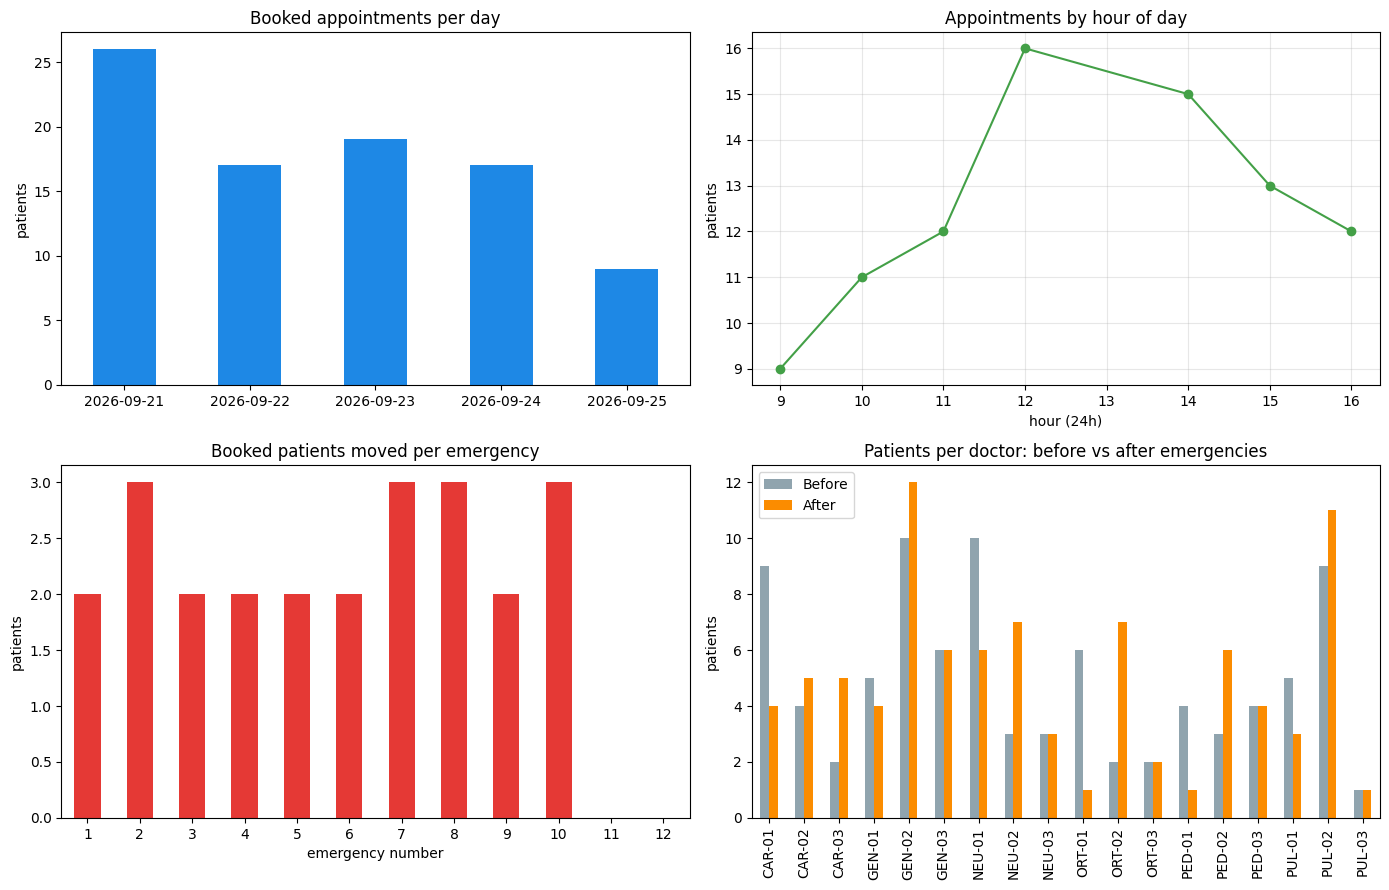

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# 1) appointments per day
schedule.appointment_date.value_counts().sort_index().plot.bar(ax=ax[0, 0], color="#1e88e5", rot=0)
ax[0, 0].set_title("Booked appointments per day")
ax[0, 0].set_xlabel("")
ax[0, 0].set_ylabel("patients")

# 2) appointments per hour (line)
per_hour = (schedule.minute // 60).value_counts().sort_index()
ax[0, 1].plot(per_hour.index, per_hour.values, marker="o", color="#43a047")
ax[0, 1].set_title("Appointments by hour of day")
ax[0, 1].set_xlabel("hour (24h)")
ax[0, 1].set_ylabel("patients")
ax[0, 1].grid(alpha=0.3)

# 3) patients displaced per emergency
er_events.patients_moved.plot.bar(ax=ax[1, 0], color="#e53935", rot=0)
ax[1, 0].set_xticklabels(range(1, len(er_events) + 1))
ax[1, 0].set_title("Booked patients moved per emergency")
ax[1, 0].set_xlabel("emergency number")
ax[1, 0].set_ylabel("patients")

# 4) doctor workload before vs after
workload = pd.DataFrame({"Before": schedule.original_doctor.value_counts(),
                         "After": schedule.doctor_id.value_counts()}).fillna(0)
workload.index = workload.index.str[4:]          # DOC-CAR-01 -> CAR-01
workload.sort_index().plot.bar(ax=ax[1, 1], color=["#90a4ae", "#fb8c00"])
ax[1, 1].set_title("Patients per doctor: before vs after emergencies")
ax[1, 1].set_xlabel("")
ax[1, 1].set_ylabel("patients")

plt.tight_layout()
plt.show()

## Step 13 — Save the files

In [13]:
schedule.to_csv("final_schedule_simple.csv", index=False)
messages.to_csv("confirmation_messages_simple.csv", index=False)
er_events.to_csv("emergency_events_simple.csv", index=False)
print("Saved: final_schedule_simple.csv, confirmation_messages_simple.csv, emergency_events_simple.csv")

Saved: final_schedule_simple.csv, confirmation_messages_simple.csv, emergency_events_simple.csv


## ✅ Done
Emergency patients were seen at once, booked patients moved to another doctor **at the same time**, and everyone got a confirmation.